In [2]:
import pandas as pd
df = pd.read_csv("FitbitHourly.csv")
df.head()

,PARTICIPANTIDENTIFIER,STUDY_USER_ID,time_utc,date_utc,hour_of_day_utc,appleSteps,appleStepsMissing,appleHRAvg,appleHRMin,appleHRMax,...,garminHRMax,garminHRVAvg,garminSleepMinutes,garminStepsMissing,garminHRMissing,garminHRVMissing,garminSleepMissing,moodScore,messageSent,messageStrategy
0,MDH-5816-7842,2377610.0,2024-06-01 00:00:00+00,2024-06-01,0,1270.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,MDH-5816-7842,2377610.0,2024-06-01 01:00:00+00,2024-06-01,1,1248.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,MDH-5816-7842,2377610.0,2024-06-01 02:00:00+00,2024-06-01,2,2297.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,MDH-5816-7842,2377610.0,2024-06-01 03:00:00+00,2024-06-01,3,552.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,MDH-5816-7842,2377610.0,2024-06-01 04:00:00+00,2024-06-01,4,346.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [10]:
# count number of rows for each participant
df.groupby('PARTICIPANTIDENTIFIER').size().sort_values(ascending=False)

PARTICIPANTIDENTIFIER
MDH-0025-5702    9648
MDH-6877-1247    9648
MDH-6846-9631    9648
MDH-6765-8644    9648
MDH-6750-6391    9648
                 ... 
MDH-2943-5205    9648
MDH-2940-4522    9648
MDH-2883-9326    9648
MDH-2820-6590    9648
MDH-9954-7688    9648
Length: 299, dtype: int64

In [ ]:
# July 1 to September 30 and readjust back to local time

prune_df = df[(df["date_utc"] >= "2024-07-01") & (df["date_utc"] <= "2024-09-30")]
prune_df.groupby('PARTICIPANTIDENTIFIER').size().sort_values(ascending=False)

PARTICIPANTIDENTIFIER
MDH-0025-5702    2208
MDH-6877-1247    2208
MDH-6846-9631    2208
MDH-6765-8644    2208
MDH-6750-6391    2208
                 ... 
MDH-2943-5205    2208
MDH-2940-4522    2208
MDH-2883-9326    2208
MDH-2820-6590    2208
MDH-9954-7688    2208
Length: 299, dtype: int64

In [14]:
# participants with Fitbit steps data for at least half of their hourly rows -> need at least 1104 rows filled out

valid_ids = (
    prune_df.groupby('PARTICIPANTIDENTIFIER')['fitbitStepsMissing']
      .sum()
      .loc[lambda x: x <= 1104]
      .index
)

prune_df = prune_df[prune_df['PARTICIPANTIDENTIFIER'].isin(valid_ids)]
prune_df.groupby('PARTICIPANTIDENTIFIER').size().sort_values(ascending=False)

PARTICIPANTIDENTIFIER
MDH-0110-2314    2208
MDH-5510-3078    2208
MDH-6275-2645    2208
MDH-5842-1531    2208
MDH-5835-0474    2208
                 ... 
MDH-2704-9429    2208
MDH-2607-7244    2208
MDH-2454-9629    2208
MDH-2399-1254    2208
MDH-9866-2341    2208
Length: 78, dtype: int64

Non-Missing Buckets

In [15]:
nonMissing = prune_df[prune_df['fitbitStepsMissing'] == 0]
nonMissing.groupby('PARTICIPANTIDENTIFIER')['fitbitSteps'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
)

,mean,median,std,min,max,count
PARTICIPANTIDENTIFIER,,,,,,
MDH-0110-2314,403.716029,209.0,491.395556,4.0,3848.0,1229
MDH-0265-4204,495.801573,322.0,799.207335,4.0,8415.0,1653
MDH-0292-0375,627.853059,348.0,859.469698,4.0,8045.0,1749
MDH-0524-6939,435.641725,242.0,607.565602,4.0,6582.0,1577
MDH-0687-9572,355.473586,176.0,466.177024,4.0,4209.0,1609
...,...,...,...,...,...,...
MDH-9336-4901,492.999430,317.0,567.564408,4.0,4789.0,1753
MDH-9459-4393,496.771595,383.5,462.433005,1.0,2944.0,1204
MDH-9618-4357,360.700306,275.0,377.020295,4.0,4941.0,1635


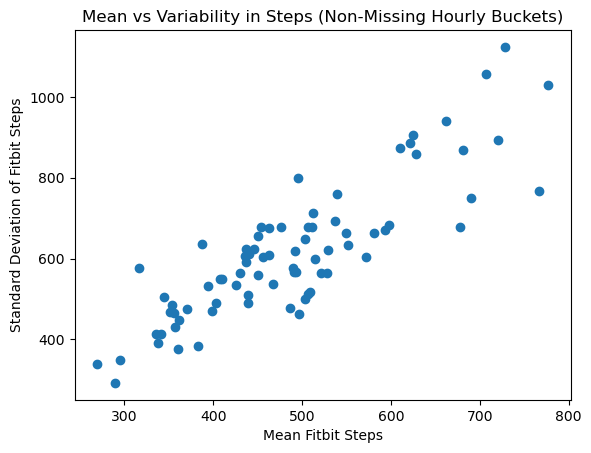

In [20]:
import matplotlib.pyplot as plt

stats = nonMissing.groupby('PARTICIPANTIDENTIFIER')['fitbitSteps'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
).reset_index()

plt.scatter(stats['mean'], stats['std'])
plt.xlabel('Mean Fitbit Steps')
plt.ylabel('Standard Deviation of Fitbit Steps')
plt.title('Mean vs Variability in Steps (Non-Missing Hourly Buckets)')
plt.show()

Missing Buckets

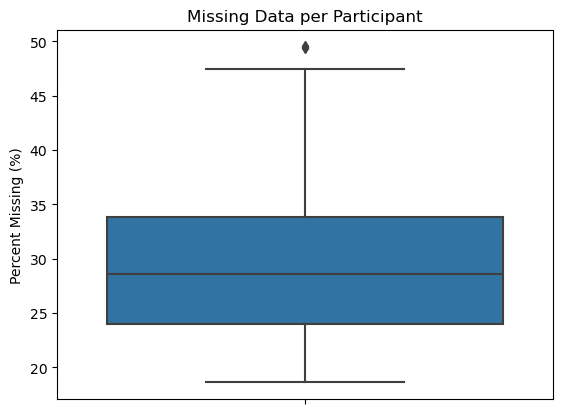

In [18]:
missing = prune_df[prune_df['fitbitStepsMissing'] == 1]
counts = missing.groupby('PARTICIPANTIDENTIFIER').size()
percent_missing = (counts / 2208) * 100

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(y=percent_missing)
plt.ylabel('Percent Missing (%)')
plt.title('Missing Data per Participant')
plt.show()

In [19]:
counts.describe()

count      78.000000
mean      665.782051
std       178.281817
min       411.000000
25%       530.000000
50%       631.000000
75%       747.000000
max      1094.000000
dtype: float64